## Add available geomorphological information to the **Final Dataset** ##

In [1]:
import pandas as pd
import missingno
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [4]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2022.csv', encoding=enc)
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [5]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2022-01-01,θεσσαλιας,αγιας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,661.8,10705.0,17.3,45.76610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.011429,12.470000,7.552857,5.780605,2.219699,9.428243,2.257183,10.448923,2.273378,21.082403,7.695856,0.000000,0.000000,0.000000,6,0,0
1,22.69237,39.13639,2022-01-01,θεσσαλιας,αλμυρου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,905.4,16004.0,20.6,45.23937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.749306,12.377500,7.121111,8.616825,1.801932,11.624984,2.821047,13.074072,2.638302,22.638515,9.655879,0.000138,0.000138,0.000138,5,0,0
2,24.07379,39.32896,2022-01-01,θεσσαλιας,αλοννησου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,129.6,3153.0,21.2,46.11198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.810000,10.958000,8.247143,12.676154,7.583333,12.528000,7.086364,19.002632,12.403333,0.453699,0.453699,0.453699,1,0,0
3,21.43051,39.22138,2022-01-01,θεσσαλιας,αργιθεας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,372.9,3515.0,9.3,44.69433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.273333,10.310000,6.236667,3.110000,-0.850636,6.849744,0.523152,6.386697,-1.146587,18.678205,6.829016,0.455287,0.455287,0.455287,12,0,0
4,22.88380,39.35198,2022-01-01,θεσσαλιας,βολου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,385.6,138865.0,374.6,45.52194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.363333,7.776667,8.950000,10.279064,2.101397,13.378828,3.620000,14.613074,2.397455,24.653417,9.725712,0.000000,0.000000,0.000000,45,0,0


In [6]:
geomorphological.head()

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.63715,39.66477,3052.548676,129.956226,2,166.574714,47.992932,180.349082,0.0,571.901338
1,22.70702,39.75460,11271.147713,3062.222244,32,133.272361,1087.057545,157.065722,0.0,4.139724
2,22.73031,39.79054,7228.976051,128.457199,7,143.757562,1236.817763,177.791748,0.0,56.070798
3,22.77688,39.66477,9517.677436,442.116743,6,215.239966,132.347263,181.430575,0.0,40.243238
4,22.77688,39.70070,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709


In [7]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)

In [8]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 7.1851740491832965


In [9]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

In [10]:
for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [11]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')

In [12]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.75027,39.71097,2022-01-01,θεσσαλιας,αγιας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,661.8,10705.0,17.3,45.76610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.011429,12.470000,7.552857,5.780605,2.219699,9.428243,2.257183,10.448923,2.273378,21.082403,7.695856,0.000000,0.000000,0.000000,6,0,0,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709
1,22.69237,39.13639,2022-01-01,θεσσαλιας,αλμυρου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,905.4,16004.0,20.6,45.23937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.749306,12.377500,7.121111,8.616825,1.801932,11.624984,2.821047,13.074072,2.638302,22.638515,9.655879,0.000138,0.000138,0.000138,5,0,0,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750
2,24.07379,39.32896,2022-01-01,θεσσαλιας,αλοννησου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,129.6,3153.0,21.2,46.11198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.810000,10.958000,8.247143,12.676154,7.583333,12.528000,7.086364,19.002632,12.403333,0.453699,0.453699,0.453699,1,0,0,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994
3,21.43051,39.22138,2022-01-01,θεσσαλιας,αργιθεας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,372.9,3515.0,9.3,44.69433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.273333,10.310000,6.236667,3.110000,-0.850636,6.849744,0.523152,6.386697,-1.146587,18.678205,6.829016,0.455287,0.455287,0.455287,12,0,0,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140
4,22.88380,39.35198,2022-01-01,θεσσαλιας,βολου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,385.6,138865.0,374.6,45.52194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.363333,7.776667,8.950000,10.279064,2.101397,13.378828,3.620000,14.613074,2.397455,24.653417,9.725712,0.000000,0.000000,0.000000,45,0,0,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743


<AxesSubplot:>

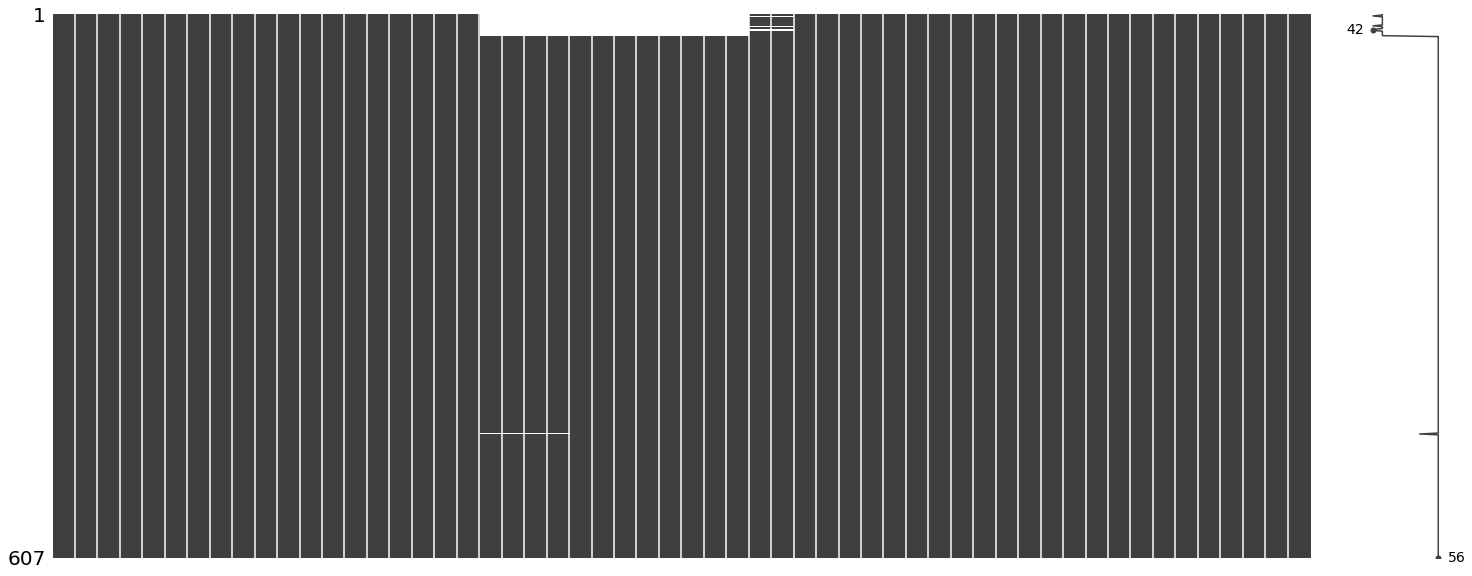

In [13]:
missingno.matrix(dataset)

In [14]:
cols = dataset.columns

In [15]:
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'mosq_pred', 'mosq_previous', 'case', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m'],
      dtype='object')

In [16]:
len(cols)

56

In [17]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case']

In [18]:
len(rearranged)

56

In [19]:
dataset = dataset[rearranged]

In [20]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2022.csv", encoding = enc, index = False)